# XGBoost API Tutorial

This notebook explores the XGBoost API for building a classification model to predict flight delays.

- **Objective**: Understand how to use XGBoost for binary classification with class imbalance
- **Reference**: See `AirlineDelay.API.md` for detailed documentation
- **Dataset**: US Airline On-Time Performance Dataset (Kaggle)

## Overview

XGBoost (Extreme Gradient Boosting) is a powerful machine learning library that excels at structured/tabular data classification and regression tasks. This notebook demonstrates:
- XGBoost classifier setup and configuration
- Handling class imbalance in flight delay prediction
- Feature importance analysis
- Model evaluation metrics (precision, recall, F1-score, ROC-AUC)

In [24]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 31.6 MB/s eta 0:00:00


## Imports

In [37]:
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)
import xgboost as xgb
import warnings

warnings.filterwarnings('ignore')
# Set up logging.
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
_LOG = logging.getLogger(__name__)

## Configuration

In [40]:
# Configure plotting style.
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

_LOG.info("XGBoost API Tutorial - Flight Delay Prediction")

2025-11-08 11:25:40,752 - __main__ - INFO - XGBoost API Tutorial - Flight Delay Prediction


## Notebook Flow

This notebook follows a structured approach:
1. **XGBoost Setup** - Initialize XGBoost classifier with appropriate parameters
2. **Class Imbalance Handling** - Configure scale_pos_weight for imbalanced datasets
3. **Model Training** - Train XGBoost on flight delay data
4. **Evaluation** - Compute precision, recall, F1-score, and ROC-AUC
5. **Feature Importance** - Visualize and analyze feature importance
6. **Model Interpretation** - Understand which factors contribute most to delays

In [43]:
## 1. XGBoost Classifier Setup

# Example: Initialize XGBoost classifier for binary classification.
# Key parameters for flight delay prediction:
# - objective: 'binary:logistic' for binary classification
# - scale_pos_weight: Automatically calculated to handle class imbalance
# - max_depth: Controls tree depth (default: 6)
# - learning_rate: Step size shrinkage (default: 0.3)
# - n_estimators: Number of boosting rounds
# - eval_metric: Evaluation metric (e.g., 'auc', 'logloss')

_LOG.info("Setting up XGBoost classifier parameters")

# Example parameters (will be used when we have data).
xgb_params = {
    'objective': 'binary:logistic',
    'max_depth': 6,
    'learning_rate': 0.1,
    'n_estimators': 100,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'eval_metric': 'auc',
    'random_state': 42,
    'use_label_encoder': False,
}

print("XGBoost Parameters:")
for key, value in xgb_params.items():
    print(f"  {key}: {value}")


2025-11-08 11:25:42,917 - __main__ - INFO - Setting up XGBoost classifier parameters


XGBoost Parameters:
  objective: binary:logistic
  max_depth: 6
  learning_rate: 0.1
  n_estimators: 100
  subsample: 0.8
  colsample_bytree: 0.8
  eval_metric: auc
  random_state: 42
  use_label_encoder: False


## 2. Handling Class Imbalance

For flight delay prediction, most flights are on-time (majority class) while delayed flights are the minority class. XGBoost provides the `scale_pos_weight` parameter to handle this imbalance.

### Calculating scale_pos_weight

The `scale_pos_weight` parameter should be set to:
```
scale_pos_weight = (number of negative samples) / (number of positive samples)
```

This helps the model focus more on correctly classifying the minority class (delayed flights).

In [46]:
# Example: Calculate scale_pos_weight for class imbalance.
# In practice, this would be calculated from actual training data.
def calculate_scale_pos_weight(y):
    """
    Calculate scale_pos_weight for XGBoost to handle class imbalance.
    
    :param y: Target variable (1 for delayed, 0 for on-time)
    :return: scale_pos_weight value
    """
    negative_count = (y == 0).sum()
    positive_count = (y == 1).sum()
    scale_pos_weight = negative_count / positive_count if positive_count > 0 else 1.0
    return scale_pos_weight

# Example usage (with dummy data for demonstration).
example_y = np.array([0, 0, 0, 0, 0, 1, 1])  # 5 on-time, 2 delayed
scale_pos_weight = calculate_scale_pos_weight(example_y)
print(f"Example scale_pos_weight: {scale_pos_weight:.2f}")
print("This means the model will weight positive samples (delays) more heavily.")


Example scale_pos_weight: 2.50
This means the model will weight positive samples (delays) more heavily.


## 3. Model Training Example

The following shows how to train an XGBoost classifier. In practice, you would load your flight delay data and use it here.


In [49]:
# Example: Train XGBoost classifier (with synthetic data for demonstration).
# In practice, replace this with your actual flight delay dataset.

# Create synthetic data for demonstration.
np.random.seed(42)
n_samples = 1000
n_features = 10

X = np.random.rand(n_samples, n_features)
y = np.random.randint(0, 2, n_samples)

# Split data into training and validation sets.
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Calculate scale_pos_weight for class imbalance.
scale_pos_weight = calculate_scale_pos_weight(y_train)
print(f"Class distribution - On-time: {(y_train == 0).sum()}, Delayed: {(y_train == 1).sum()}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# Initialize XGBoost classifier.
xgb_classifier = xgb.XGBClassifier(
    objective='binary:logistic',
    max_depth=6,
    learning_rate=0.1,
    n_estimators=100,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=42,
    use_label_encoder=False,
)

# Train the model.
_LOG.info("Training XGBoost classifier")
xgb_classifier.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print("Model training completed!")


2025-11-08 11:25:46,353 - __main__ - INFO - Training XGBoost classifier


Class distribution - On-time: 388, Delayed: 412
scale_pos_weight: 0.94
Model training completed!


## 4. Model Evaluation

Evaluate the model using precision, recall, F1-score, and ROC-AUC metrics. These metrics are important for imbalanced classification problems.


In [52]:
# Make predictions.
y_pred = xgb_classifier.predict(X_val)
y_pred_proba = xgb_classifier.predict_proba(X_val)[:, 1]

# Calculate evaluation metrics.
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_pred_proba)

# Print metrics.
print("Model Evaluation Metrics:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")

# Confusion matrix.
cm = confusion_matrix(y_val, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Classification report.
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=['On-time', 'Delayed']))


Model Evaluation Metrics:
  Accuracy:  0.5300
  Precision: 0.5437
  Recall:    0.5437
  F1-Score:  0.5437
  ROC-AUC:   0.5278

Confusion Matrix:
[[50 47]
 [47 56]]

Classification Report:
              precision    recall  f1-score   support

     On-time       0.52      0.52      0.52        97
     Delayed       0.54      0.54      0.54       103

    accuracy                           0.53       200
   macro avg       0.53      0.53      0.53       200
weighted avg       0.53      0.53      0.53       200



## 5. Feature Importance

XGBoost provides feature importance scores that help understand which features contribute most to delay predictions. This is crucial for understanding delay factors (weather vs. airline vs. airport).


Top 10 Most Important Features (by gain):
     feature      gain  weight
5  feature_5  1.891463   257.0
3  feature_3  1.877017   246.0
6  feature_6  1.874718   230.0
9  feature_9  1.831597   257.0
1  feature_1  1.815931   242.0
4  feature_4  1.814203   275.0
8  feature_8  1.658264   243.0
2  feature_2  1.651335   260.0
7  feature_7  1.615136   246.0
0  feature_0  1.530362   207.0


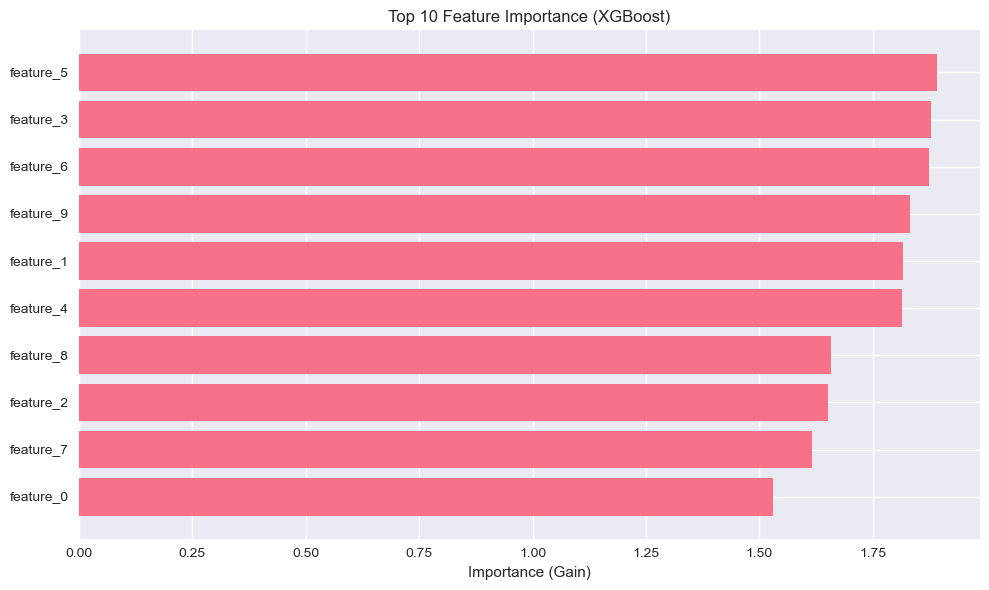

In [55]:
# Get feature importance scores.
# XGBoost provides different importance types: 'weight', 'gain', 'cover'
importance_gain = xgb_classifier.get_booster().get_score(importance_type='gain')
importance_weight = xgb_classifier.get_booster().get_score(importance_type='weight')

# Convert to DataFrame for easier visualization.
feature_names = [f'feature_{i}' for i in range(n_features)]
importance_df = pd.DataFrame({
    'feature': feature_names,
    'gain': [importance_gain.get(f'f{i}', 0) for i in range(n_features)],
    'weight': [importance_weight.get(f'f{i}', 0) for i in range(n_features)],
})

# Sort by gain (most commonly used).
importance_df = importance_df.sort_values('gain', ascending=False)

print("Top 10 Most Important Features (by gain):")
print(importance_df.head(10))

# Visualize feature importance.
plt.figure(figsize=(10, 6))
plt.barh(importance_df.head(10)['feature'], importance_df.head(10)['gain'])
plt.xlabel('Importance (Gain)')
plt.title('Top 10 Feature Importance (XGBoost)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 6. ROC Curve Visualization

Plot the ROC curve to visualize the model's ability to distinguish between on-time and delayed flights.


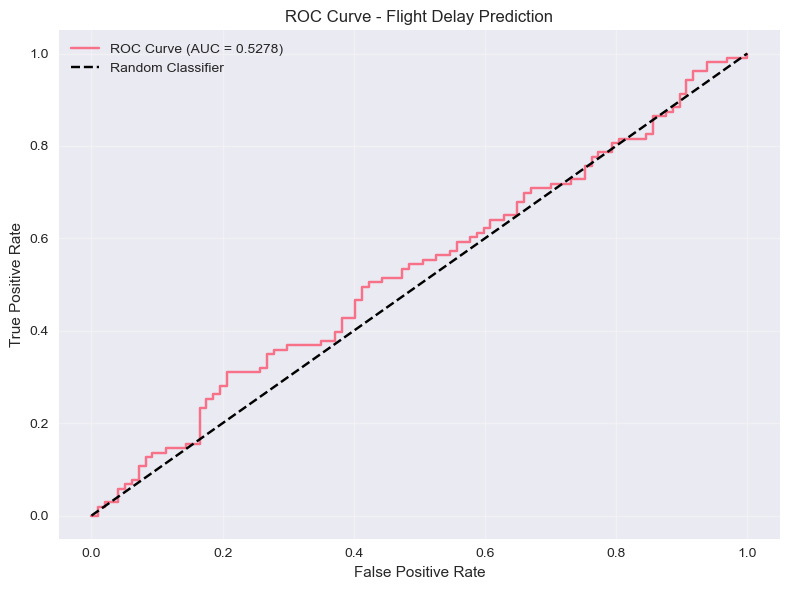

In [58]:
# Plot ROC curve.
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Flight Delay Prediction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Summary

This notebook demonstrated:
1. **XGBoost Setup**: Configuring XGBoost classifier for binary classification
2. **Class Imbalance**: Handling imbalanced datasets with `scale_pos_weight`
3. **Model Training**: Training XGBoost with validation set monitoring
4. **Evaluation**: Computing precision, recall, F1-score, and ROC-AUC metrics
5. **Feature Importance**: Analyzing which features contribute most to predictions
6. **Visualization**: Plotting ROC curves and feature importance

For the full implementation with real flight delay data, see `AirlineDelay.example.ipynb`.
